In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

In [3]:
dataset = load_diabetes()
print(dataset)

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10)), 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59

| Short name | Meaning                      |
| ---------- | ---------------------------- |
| age        | age in years                 |
| sex        | gender                       |
| bmi        | body mass index              |
| bp         | average blood pressure       |
| s1         | total serum cholesterol (tc) |
| s2         | LDL cholesterol              |
| s3         | HDL cholesterol              |
| s4         | total cholesterol / HDL      |
| s5         | log of triglycerides         |
| s6         | blood sugar level            |


In [4]:
X = dataset.data
y = dataset.target
print(X.shape , y.shape)

(442, 10) (442,)


In [7]:
print(y[0:5])

[151.  75. 141. 206. 135.]


In [6]:
print(dataset.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [10]:
x_df = pd.DataFrame(X , columns=dataset.feature_names)
x_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [32]:
x_df.isnull().sum()

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

In [11]:
y_df = pd.Series(y, name="target")
y_df.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [13]:
X_train , X_test , y_train , y_test = train_test_split(x_df , y_df , test_size=0.2)
print(X_train.shape , y_train.shape , X_test.shape , y_test.shape)

(353, 10) (353,) (89, 10) (89,)


RegressionTree

In [21]:
y_train.info()

<class 'pandas.Series'>
Index: 353 entries, 11 to 396
Series name: target
Non-Null Count  Dtype  
--------------  -----  
353 non-null    float64
dtypes: float64(1)
memory usage: 5.5 KB


In [45]:
class TreeNode:
    def __init__(self , feature = None, threshold = None, left = None , right = None , value = None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def MSE(y):
    if(len(y) == 0):
        return 0.0
    
    mean_y = np.mean(y)
    n = len(y)

    return (1/n) * np.sum((y - mean_y) ** 2)

def build_tree(X , y , depth , max_depth , min_samples):

    if(len(y) <= min_samples):
        return TreeNode(value=np.mean(y))
    
    if(depth >= max_depth):
        return TreeNode(value=np.mean(y))
    
    parentMse = MSE(y)
    
    all_columns = X.columns
    max_features = max(1, int(np.sqrt(len(all_columns))))
    random_cols = np.random.choice(all_columns , size=max_features , replace=False)

    best_threshold = None
    best_feature = None
    best_infogain = float('-inf')

    for col in random_cols:

        column_values = X[col].unique()
        sorted_values = np.sort(column_values)
        median_splits = []

        for i in range(1 , len(sorted_values)):
            midpoint = (sorted_values[i - 1] + sorted_values[i]) / 2
            median_splits.append(midpoint) 
        
        for val in median_splits:
            mask = X[col] <= val
            X_left = X[mask]
            y_left = y[mask]
            X_right = X[~mask]
            y_right = y[~mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue
            left_mse = MSE(y_left)
            right_mse = MSE(y_right)

            weighted_avg = (
                ((len(y_left)/len(y)) * left_mse) + 
                ((len(y_right)/len(y)) * right_mse)
            )

            info_gain = parentMse - weighted_avg

            if(best_infogain < info_gain):
                best_infogain = info_gain
                best_threshold = val
                best_feature = col
                
    if best_feature is None or best_infogain <= 0:
        return TreeNode(value=np.mean(y))

    left_mask = X[best_feature] <= best_threshold
    right_mask = X[best_feature] > best_threshold
    left_subtree = build_tree(X[left_mask] , y[left_mask] , depth + 1 , max_depth , min_samples)
    right_subtree = build_tree(X[right_mask] , y[right_mask] , depth + 1 , max_depth , min_samples)
    return TreeNode(
        feature=best_feature,
        threshold=best_threshold,
        left=left_subtree,
        right=right_subtree,
        value=None
    )    


In [46]:
class Bagging:

    def __init__(self , X , y , no_of_trees , max_depth , no_samples):

        self.X = X
        self.y = y
        self.no_of_trees = no_of_trees
        self.max_depth = max_depth
        self.no_samples = no_samples
        self.trees = []

    def bootstrap_sample(self):

        n_samples = len(self.X)
        indices = np.random.choice(n_samples , size=n_samples , replace=True)
        X_bootstrap = self.X.iloc[indices]
        y_bootstrap = self.y.iloc[indices]
        return X_bootstrap , y_bootstrap
    
    def train_forest(self):

        for _ in range(self.no_of_trees):

            bootstrap_x , bootstrap_y = self.bootstrap_sample(  )
            tree = build_tree(bootstrap_x , bootstrap_y , 0 , self.max_depth , self.no_samples)
            self.trees.append(tree)

    def predict_one(self , node , x):

        if node.value is not None:
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self.predict_one(node.left, x)
        
        else:
            return self.predict_one(node.right, x)
        
    def predict(self, X_t):
        predictions = []

        for i in range(len(X_t)):
            row = X_t.iloc[i]
            tree_preds = []

            for tree in self.trees:
                tree_preds.append(self.predict_one(tree, row))

            predictions.append(np.mean(tree_preds))

        return np.array(predictions)

            



        

    
    

In [47]:
assert (X_train.index == y_train.index).all()
assert (X_test.index == y_test.index).all()


In [48]:
rf = Bagging(
    X=X_train,
    y=y_train,
    no_of_trees=50,     # number of trees
    max_depth=6,        # tree depth
    no_samples=5        # min samples per leaf
)


In [49]:
rf.train_forest()

In [50]:
y_pred = rf.predict(X_test)


In [51]:
import pandas as pd

results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results_df["Error"] = results_df["Actual"] - results_df["Predicted"]
results_df


,Actual,Predicted,Error
0,80.0,94.044257,-14.044257
1,96.0,90.802487,5.197513
2,71.0,98.903088,-27.903088
3,51.0,103.276035,-52.276035
4,170.0,139.560145,30.439855
...,...,...,...
84,158.0,94.233747,63.766253
85,134.0,153.283537,-19.283537
86,137.0,195.083892,-58.083892
87,281.0,179.671689,101.328311


In [52]:
mse = np.mean((y_test.values - y_pred) ** 2)
print("MSE:", mse)


MSE: 3320.383349039051


In [53]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 57.62276762738016


In [55]:
np.mean(y_test)

np.float64(141.41573033707866)

In [54]:
print(np.std(y_test) > rmse)

True


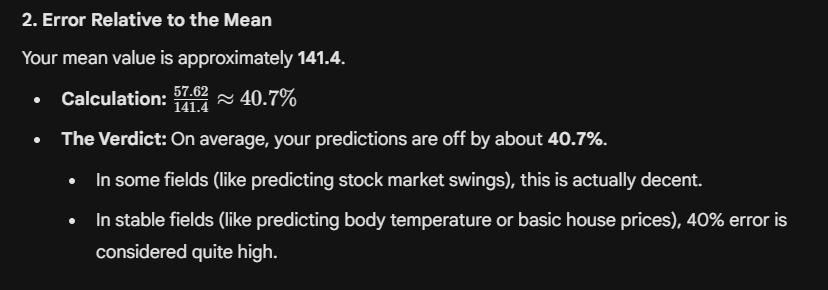